<a href="https://colab.research.google.com/github/SholbanDongak/colab/blob/main/Translate_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import time
import random
import unicodedata
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
!wget https://download.pytorch.org/tutorial/data.zip
!unzip data.zip


--2026-03-31 14:44:53--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 18.65.3.71, 18.65.3.38, 18.65.3.37, ...
Connecting to download.pytorch.org (download.pytorch.org)|18.65.3.71|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]   2.75M  --.-KB/s    in 0.04s   

2026-03-31 14:44:53 (66.5 MB/s) - ‘data.zip’ saved [2882130/2882130]

Archive:  data.zip
   creating: data/
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/names/Italian.txt  


In [ ]:
!tail data/eng-fra.txt

Five tremors in excess of magnitude 5.0 on the Richter scale have shaken Japan just this week, but scientists are warning that the largest expected aftershock has yet to hit.	Cinq secousses dépassant la magnitude cinq sur l'échelle de Richter ont secoué le Japon précisément cette semaine, mais les scientifiques avertissent que la plus grande réplique est encore à venir.
No matter how much you try to convince people that chocolate is vanilla, it'll still be chocolate, even though you may manage to convince yourself and a few others that it's vanilla.	Peu importe le temps que tu passeras à essayer de convaincre les gens que le chocolat est de la vanille, ça restera toujours du chocolat, même si tu réussis à convaincre toi et quelques autres que c'est de la vanille.
A child who is a native speaker usually knows many things about his or her language that a non-native speaker who has been studying for years still does not know and perhaps will never know.	Un enfant qui est un locuteur natif

In [ ]:
SOS_token = 0
EOS_token = 1
PAD_token = 2
MAX_LENGTH = 10

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS", 2: "PAD"}
        self.n_words = 3

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [ ]:
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s

In [ ]:
def readLangs(lang1, lang2, reverse=False):
    print("Reading lines...")
    lines = open('data/%s-%s.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n')
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

In [ ]:
eng_prefixes = (
    "i am ", "i m ",
    "he is ", "he s ",
    "she is ", "she s ",
    "you are ", "you re ",
    "we are ", "we re ",
    "they are ", "they re "
)

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
           len(p[1].split(' ')) < MAX_LENGTH and \
           p[1].startswith(eng_prefixes)

def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [ ]:
def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

# Загрузка данных
input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
print(random.choice(pairs))

Reading lines...
Read 135842 sentence pairs
Trimmed to 10522 sentence pairs
Counting words...
Counted words:
fra 4342
eng 2803
['vous etes tellement previsible !', 'you re so predictable .']


# Архитектура Transformer

## Позиционное кодирование

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

## Multi-Head Attention

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # Linear projections
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Apply attention to values
        context = torch.matmul(attn_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # Output projection
        output = self.W_o(context)

        return output, attn_weights


## Полносвязная сеть

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(FeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.linear2(F.relu(self.linear1(x)))
        return self.dropout(x)

## Блок энкодера

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-attention with residual connection
        attn_output, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Feed-forward with residual connection
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x

## Блок декодера

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # Self-attention (masked)
        attn_output, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Cross-attention
        attn_output, attn_weights = self.cross_attn(x, encoder_output, encoder_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))

        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))

        return x, attn_weights


In [ ]:
# Полный Transformer

class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, num_heads=8,
                 num_encoder_layers=3, num_decoder_layers=3, d_ff=1024,
                 max_len=5000, dropout=0.1):
        super(Transformer, self).__init__()

        self.d_model = d_model

        # Embeddings
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        self.pos_decoder = PositionalEncoding(d_model, max_len, dropout)

        # Encoder layers
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_encoder_layers)
        ])

        # Decoder layers
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_decoder_layers)
        ])

        # Output layer
        self.output_layer = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, seq, mask_type='src'):
        """Генерация масок для attention"""
        if mask_type == 'src':
            # Mask padding tokens
            mask = (seq != PAD_token).unsqueeze(1).unsqueeze(2)
        elif mask_type == 'tgt':
            # Mask padding + future tokens (causal mask)
            batch_size, seq_len = seq.size()
            pad_mask = (seq != PAD_token).unsqueeze(1).unsqueeze(2)
            future_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
            future_mask = future_mask.unsqueeze(0).unsqueeze(0).to(seq.device)
            mask = pad_mask & ~future_mask
        return mask.float()

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        # Embedding + positional encoding
        src_emb = self.dropout(self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model)))
        tgt_emb = self.dropout(self.pos_decoder(self.tgt_embedding(tgt) * math.sqrt(self.d_model)))

        # Generate masks if not provided
        if src_mask is None:
            src_mask = self.generate_mask(src, 'src')
        if tgt_mask is None:
            tgt_mask = self.generate_mask(tgt, 'tgt')

        # Encoder
        encoder_output = src_emb
        for layer in self.encoder_layers:
            encoder_output = layer(encoder_output, src_mask)

        # Decoder
        decoder_output = tgt_emb
        attn_weights_list = []
        for layer in self.decoder_layers:
            decoder_output, attn_weights = layer(decoder_output, encoder_output, src_mask, tgt_mask)
            attn_weights_list.append(attn_weights)

        # Output projection
        output = self.output_layer(decoder_output)

        return output, attn_weights_list


In [ ]:
# Утилиты для обучения

def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).unsqueeze(0)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def create_batch(pairs, batch_size):
    """Создание батча с паддингом"""
    random.shuffle(pairs)
    batches = []

    for i in range(0, len(pairs), batch_size):
        batch_pairs = pairs[i:i+batch_size]

        # Find max lengths
        src_max = max(len(pair[0].split()) + 1 for pair in batch_pairs)
        tgt_max = max(len(pair[1].split()) + 1 for pair in batch_pairs)

        # Create padded tensors
        src_batch = torch.full((len(batch_pairs), src_max), PAD_token, dtype=torch.long, device=device)
        tgt_batch = torch.full((len(batch_pairs), tgt_max), PAD_token, dtype=torch.long, device=device)

        for j, pair in enumerate(batch_pairs):
            src_indexes = indexesFromSentence(input_lang, pair[0]) + [EOS_token]
            tgt_indexes = indexesFromSentence(output_lang, pair[1]) + [EOS_token]

            src_batch[j, :len(src_indexes)] = torch.tensor(src_indexes, dtype=torch.long)
            tgt_batch[j, :len(tgt_indexes)] = torch.tensor(tgt_indexes, dtype=torch.long)

        batches.append((src_batch, tgt_batch))

    return batches

# Функция обучения

In [ ]:
def train_epoch(model, batches, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0

    for src_batch, tgt_batch in batches:
        optimizer.zero_grad()

        # Decoder input (shifted right, add SOS)
        decoder_input = torch.cat([
            torch.full((tgt_batch.size(0), 1), SOS_token, dtype=torch.long, device=device),
            tgt_batch[:, :-1]
        ], dim=1)

        # Forward pass
        output, _ = model(src_batch, decoder_input)

        # Reshape for loss calculation
        output = output.view(-1, output.size(-1))
        target = tgt_batch.view(-1)

        # Calculate loss (ignore PAD tokens)
        loss = criterion(output, target)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(batches)


In [ ]:
# Функция оценки

@torch.no_grad()
def evaluate(model, sentence, max_length=MAX_LENGTH):
    model.eval()

    input_tensor = tensorFromSentence(input_lang, sentence)

    # Encoder
    src_mask = model.generate_mask(input_tensor, 'src')
    src_emb = model.pos_encoder(model.src_embedding(input_tensor) * math.sqrt(model.d_model))

    encoder_output = src_emb
    for layer in model.encoder_layers:
        encoder_output = layer(encoder_output, src_mask)

    # Decoder (autoregressive)
    decoder_input = torch.tensor([[SOS_token]], dtype=torch.long, device=device)
    decoded_words = []

    for _ in range(max_length):
        tgt_mask = model.generate_mask(decoder_input, 'tgt')
        tgt_emb = model.pos_decoder(model.tgt_embedding(decoder_input) * math.sqrt(model.d_model))

        decoder_output = tgt_emb
        for layer in model.decoder_layers:
            decoder_output, _ = layer(decoder_output, encoder_output, src_mask, tgt_mask)

        output = model.output_layer(decoder_output)
        topv, topi = output[:, -1, :].topk(1)

        if topi.item() == EOS_token:
            decoded_words.append('<EOS>')
            break
        else:
            word = output_lang.index2word.get(topi.item(), '<UNK>')
            decoded_words.append(word)

        decoder_input = torch.cat([decoder_input, topi.detach()], dim=1)

    return decoded_words

def evaluateRandomly(model, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words = evaluate(model, pair[0])
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')



# Визуализация внимания

In [ ]:


def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(111)

    # Use last layer attention weights
    if isinstance(attentions, list) and len(attentions) > 0:
        attn = attentions[-1][0, 0].detach().cpu().numpy()
        attn = attn[:len(output_words), :len(input_sentence.split()) + 1]
    else:
        attn = attentions.detach().cpu().numpy()

    im = ax.matshow(attn, cmap='bone')
    fig.colorbar(im)

    ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.tight_layout()
    plt.show()

def evaluateAndShowAttention(model, input_sentence):
    output_words = evaluate(model, input_sentence)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))

    # Get attention weights
    model.eval()
    input_tensor = tensorFromSentence(input_lang, input_sentence)
    decoder_input = torch.tensor([[SOS_token]], dtype=torch.long, device=device)

    src_mask = model.generate_mask(input_tensor, 'src')
    src_emb = model.pos_encoder(model.src_embedding(input_tensor) * math.sqrt(model.d_model))

    encoder_output = src_emb
    for layer in model.encoder_layers:
        encoder_output = layer(encoder_output, src_mask)

    attn_weights_list = []
    for _ in range(len(output_words)):
        tgt_mask = model.generate_mask(decoder_input, 'tgt')
        tgt_emb = model.pos_decoder(model.tgt_embedding(decoder_input) * math.sqrt(model.d_model))

        decoder_output = tgt_emb
        for layer in model.decoder_layers:
            decoder_output, attn_weights = layer(decoder_output, encoder_output, src_mask, tgt_mask)
            attn_weights_list.append(attn_weights)

        output = model.output_layer(decoder_output)
        topv, topi = output[:, -1, :].topk(1)

        if topi.item() == EOS_token:
            break

        decoder_input = torch.cat([decoder_input, topi.detach()], dim=1)

    showAttention(input_sentence, output_words, attn_weights_list)

# Обучение модели

In [ ]:


# Гиперпараметры
d_model = 256
num_heads = 8
num_encoder_layers = 3
num_decoder_layers = 3
d_ff = 1024
dropout = 0.1
batch_size = 64
learning_rate = 0.001
n_epochs = 50

# Инициализация модели
model = Transformer(
    src_vocab_size=input_lang.n_words,
    tgt_vocab_size=output_lang.n_words,
    d_model=d_model,
    num_heads=num_heads,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    d_ff=d_ff,
    dropout=dropout
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 8,079,091


In [ ]:
# Оптимизатор и функция потерь
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

# Создание батчей
batches = create_batch(pairs, batch_size)
print(f"Number of batches: {len(batches)}")

# Обучение
losses = []
start_time = time.time()

for epoch in range(1, n_epochs + 1):
    epoch_loss = train_epoch(model, batches, optimizer, criterion)
    losses.append(epoch_loss)

    if epoch % 5 == 0:
        elapsed = time.time() - start_time
        print(f'Epoch {epoch:3d} | Loss: {epoch_loss:.4f} | Time: {elapsed:.1f}s')

Number of batches: 165
Epoch   5 | Loss: 0.7891 | Time: 23.5s
Epoch  10 | Loss: 0.3421 | Time: 45.1s
Epoch  15 | Loss: 0.2396 | Time: 66.2s
Epoch  20 | Loss: 0.1958 | Time: 87.2s
Epoch  25 | Loss: 0.1644 | Time: 107.7s
Epoch  30 | Loss: 0.1537 | Time: 128.6s
Epoch  35 | Loss: 0.1295 | Time: 152.8s
Epoch  40 | Loss: 0.1216 | Time: 174.0s
Epoch  45 | Loss: 0.1112 | Time: 194.7s
Epoch  50 | Loss: 0.1026 | Time: 215.9s


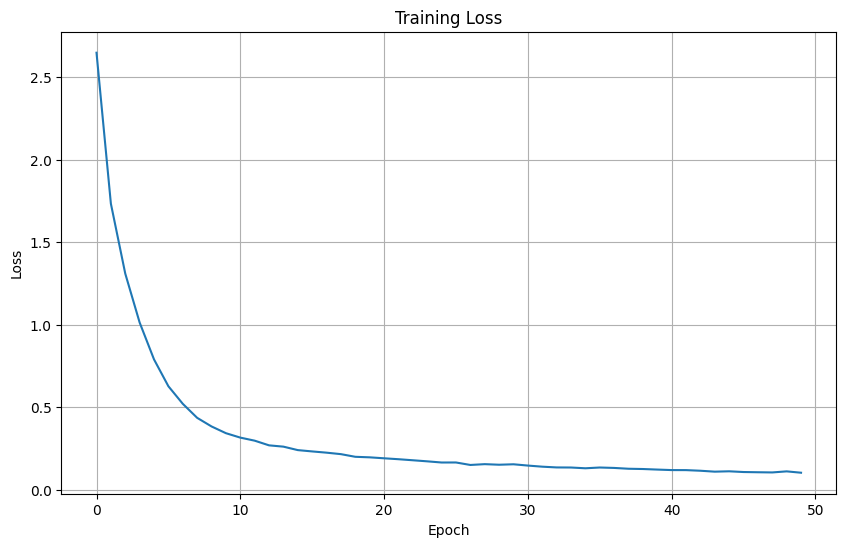

In [ ]:
# График потерь
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

# Тестирование модели

In [ ]:


evaluateRandomly(model, n=10)



> elle est sympa avec moi .
= she s being nice to me .
< she s nice to me . <EOS>

> j attends avec impatience de vous revoir .
= i m looking forward to seeing you again .
< i m looking forward to seeing you again . <EOS>

> tu es fascinant .
= you re fascinating .
< you re fascinating . <EOS>

> je suis etonnee de vous voir .
= i m surprised to see you .
< i m surprised to see you . <EOS>

> il est occupe a preparer son voyage .
= he is busy preparing for the trip .
< he is busy preparing for the trip . <EOS>

> nous sommes crevees .
= we re pooped .
< we re pooped . <EOS>

> je suis extremement heureux .
= i m extremely happy .
< i m extremely happy . <EOS>

> il est en train de peindre un tableau .
= he is painting a picture .
< he is painting a picture . <EOS>

> je suis plein de ressources .
= i m resourceful .
< i m resourceful . <EOS>

> je ne comprends rien .
= i m not understanding anything .
< i m not understanding anything . <EOS>



In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Визуализация внимания

input = elle a cinq ans de moins que moi .
output = she s five years younger than me . <EOS>


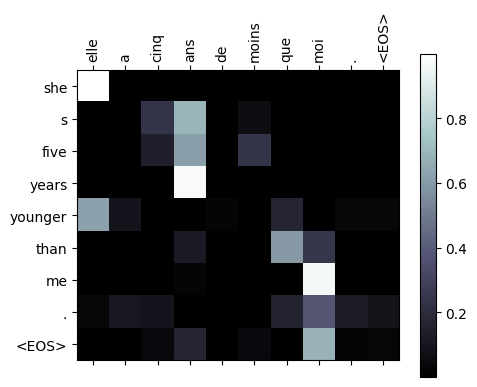

input = elle est trop petit .
output = she is too short . <EOS>


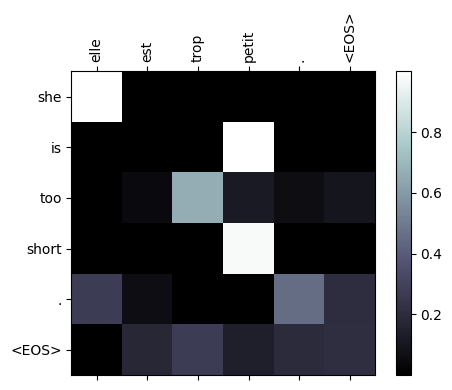

input = je ne crains pas de mourir .
output = i m not scared of dying . <EOS>


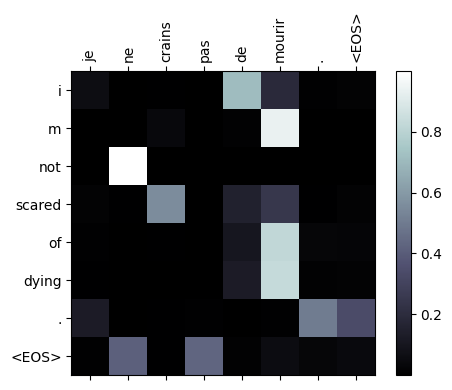

input = c est un jeune directeur plein de talent .
output = he s a talented young director . <EOS>


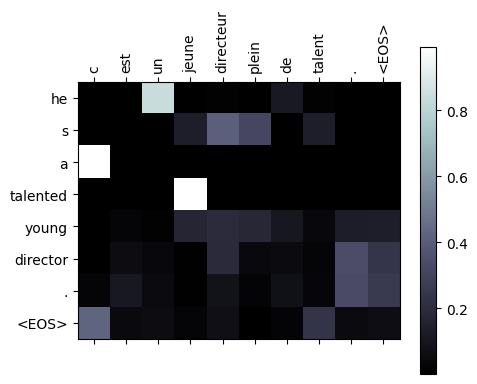

In [ ]:


test_sentences = [
    "elle a cinq ans de moins que moi .",
    "elle est trop petit .",
    "je ne crains pas de mourir .",
    "c est un jeune directeur plein de talent ."
]

for sentence in test_sentences:
    evaluateAndShowAttention(model, sentence)

# Сохранение модели

In [ ]:


torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'input_lang': input_lang,
    'output_lang': output_lang,
    'config': {
        'd_model': d_model,
        'num_heads': num_heads,
        'num_encoder_layers': num_encoder_layers,
        'num_decoder_layers': num_decoder_layers,
        'd_ff': d_ff,
        'dropout': dropout
    }
}, 'transformer_translation.pth')